In [160]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (3).csv


In [161]:
import warnings
warnings.filterwarnings('ignore')

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from operator import add
import seaborn as sns

%matplotlib inline

In [163]:
df = pd.read_csv("heart.csv")


In [164]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [166]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [167]:
df['Age'].value_counts()
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


Label Encoding

In [168]:
categorical_cols= df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [169]:
for col in categorical_cols:
  print(col,df[col].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


In [170]:
for col in categorical_cols:
    print(col, df[col].nunique())

Sex 2
ChestPainType 4
RestingECG 3
ExerciseAngina 2
ST_Slope 3


**Exploratory Data Analysis**

*Missing values*

In [171]:
#total percentage of missing data
total_percentage = (df.isnull().sum().sum() / df.size) * 100
print(f'The total percentage of missing data is {round(total_percentage,2)}%')

The total percentage of missing data is 0.0%


In [172]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [173]:
# percentage of missing data per category
import numpy as np

# convert all types of missing → NaN
df.replace(["", " ", "NA", "Unknown"], np.nan, inplace=True)

total = df.isnull().sum().sort_values(ascending=False)
percent_total = (df.isnull().sum()/len(df)).sort_values(ascending=False)*100

missing = pd.concat([total, percent_total], axis=1, keys=["Total", "Percentage"])
missing_data = missing[missing['Total'] > 0]

missing_data

,Total,Percentage


In [174]:
# drop columns where ALL values are NaN
df = df.dropna(axis=1, how='all')

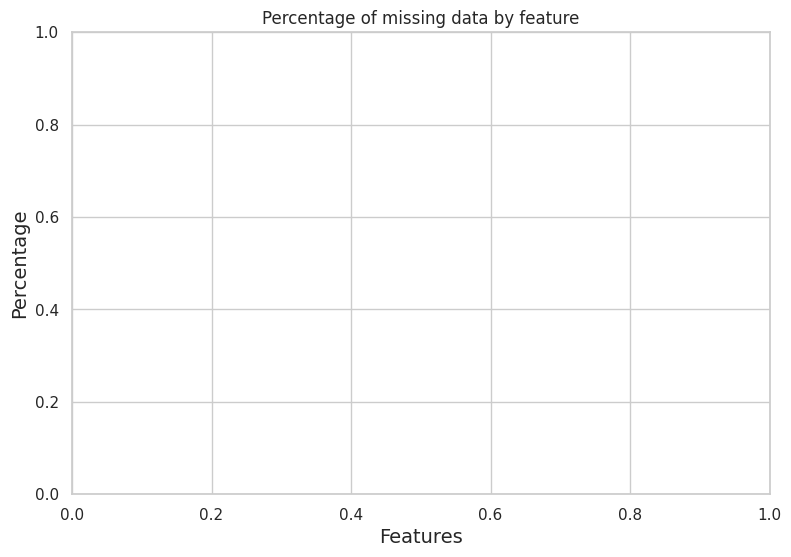

In [175]:
plt.figure(figsize=(9,6))
sns.set(style="whitegrid")
sns.barplot(x=missing_data.index, y=missing_data['Percentage'], data = missing_data)
plt.title('Percentage of missing data by feature')
plt.xlabel('Features', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.show()

In [176]:

# -----------------------------
# Step 2: Remove columns with >50% missing values
# -----------------------------
threshold = 0.5

missing_percentage = df.isnull().mean()

columns_to_drop = missing_percentage[missing_percentage > threshold].index

print("\nColumns removed:", list(columns_to_drop))

df = df.drop(columns=columns_to_drop)

# -----------------------------
# Step 3: Fill remaining missing values
# -----------------------------
for column in df.columns:

    # Numerical columns
    if df[column].dtype in ["int64", "float64"]:
        df[column].fillna(df[column].median(), inplace=True)

    # Categorical columns
    else:
        df[column].fillna(df[column].mode()[0], inplace=True)

# -----------------------------
# Step 4: Verify again
# -----------------------------
print("\nMissing values after handling:\n")
print(df.isnull().sum())


Columns removed: []

Missing values after handling:

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


*Data Distribution*

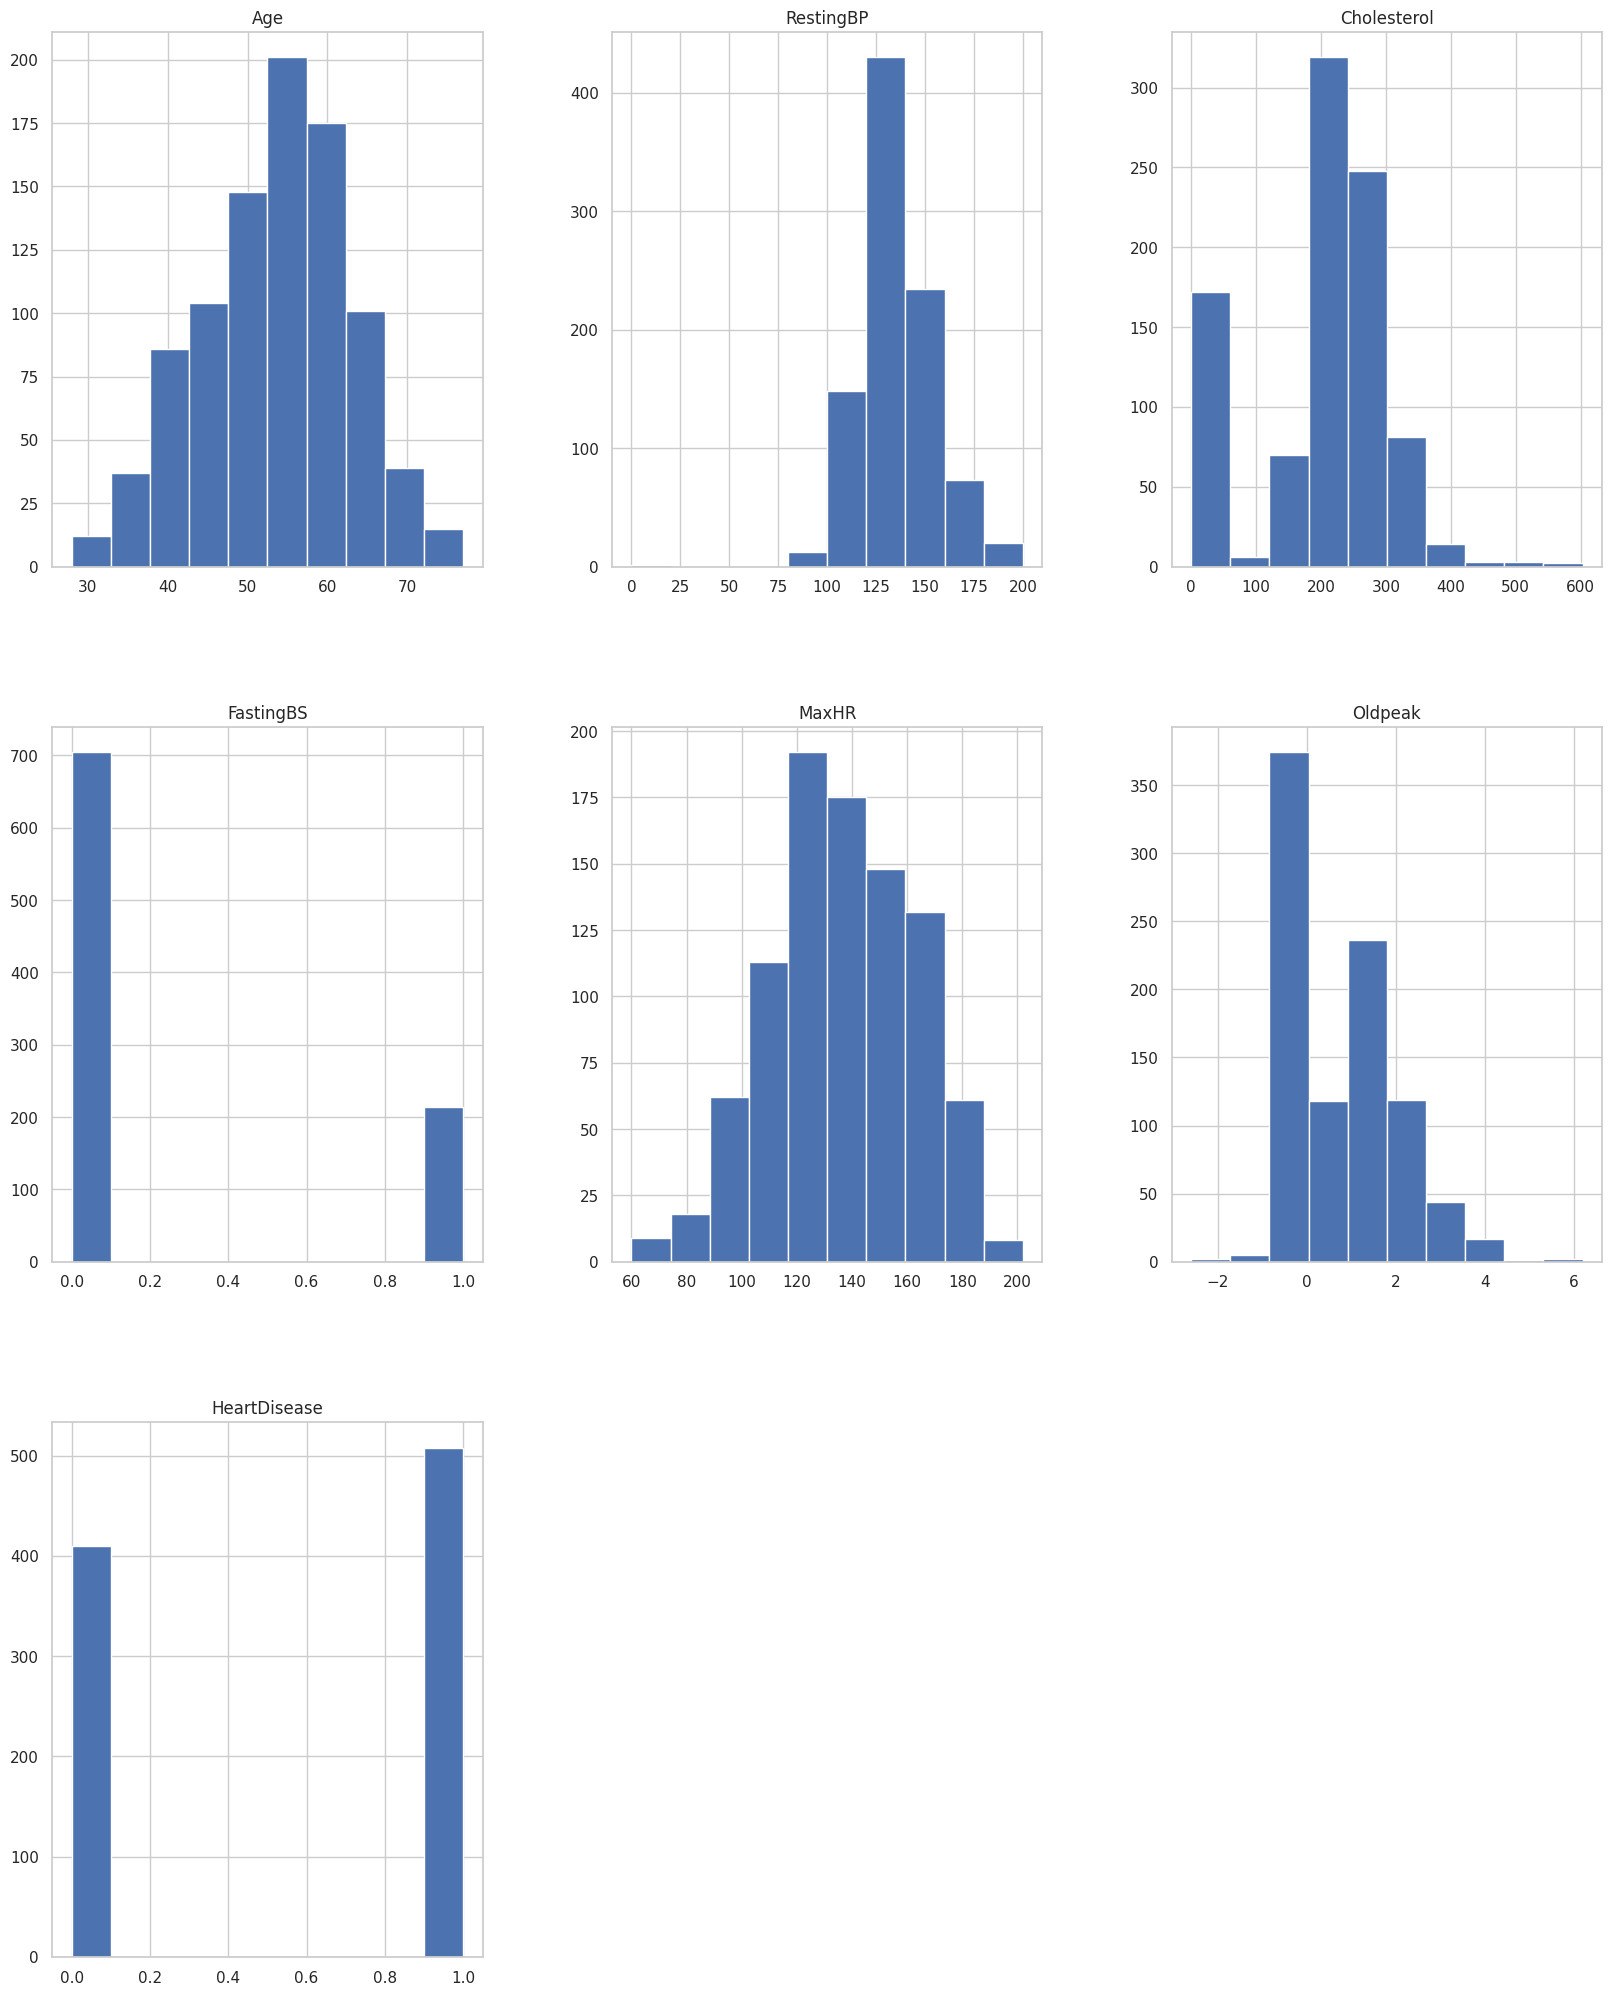

In [177]:
# plot histogram to see the distribution of the data
fig = plt.figure(figsize = (20,25))
ax = fig.gca()
df.hist(ax = ax)
plt.show()

#to check the balancing

*People with or without risk*

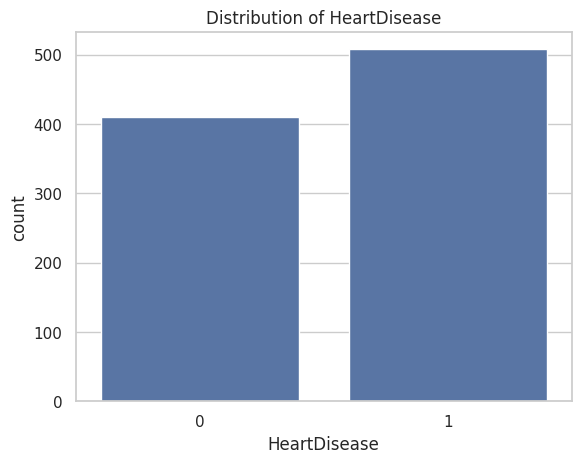

Class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [178]:
target_col = 'HeartDisease' #change according to dataset


sns.countplot(x=target_col, data=df)
plt.title(f"Distribution of {target_col}")
plt.show()

cases = df[target_col].value_counts()

print(f"Class distribution:\n{cases}")

***Features and Heart attack Risk***

In [179]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


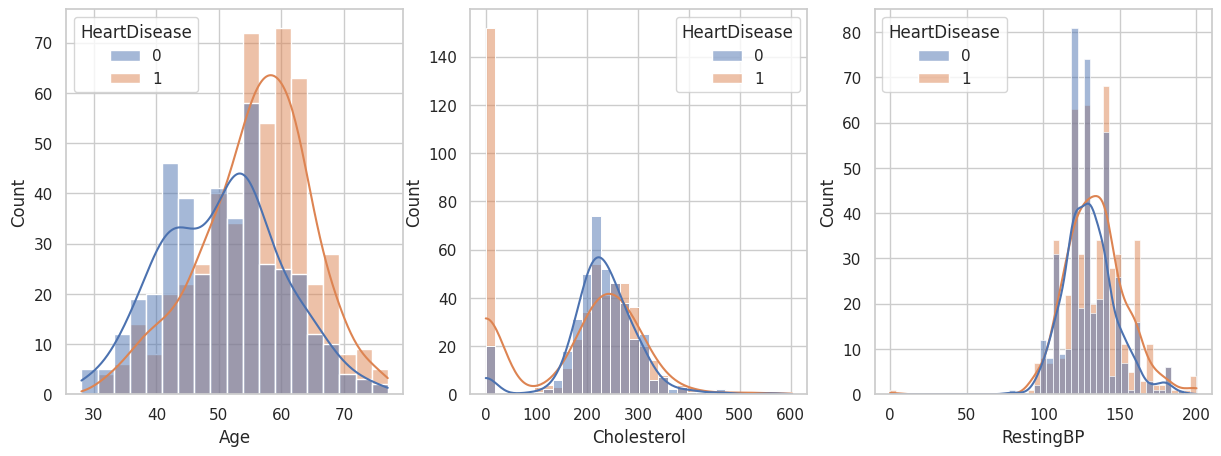

In [180]:
features = ['Age','Cholesterol','RestingBP']
target = 'HeartDisease'

plt.figure(figsize=(20,5))

for i, feature in enumerate(features):
    plt.subplot(1,4,i+1)
    sns.histplot(data=df, x=feature, hue=target, kde=True)

plt.show()

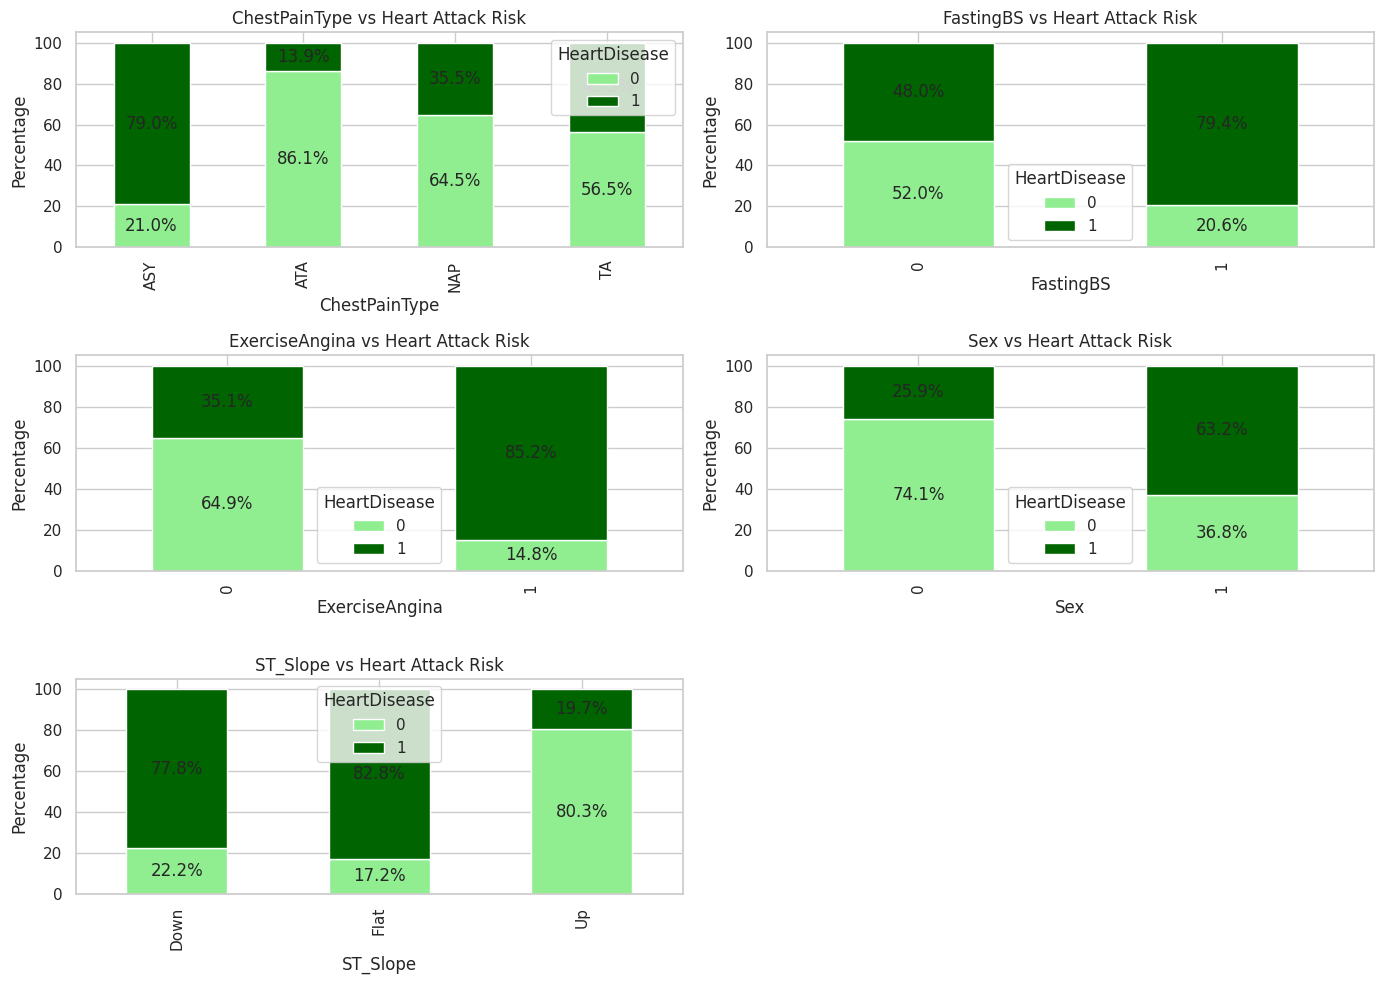

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Re-load the original dataset for this specific visualization
# This ensures we work with the original categorical columns before one-hot encoding
temp_df_for_plot = pd.read_csv('heart.csv')

# Apply Label Encoding for binary categorical columns that were encoded earlier
le = LabelEncoder()
temp_df_for_plot['Sex'] = le.fit_transform(temp_df_for_plot['Sex']) # M/F -> 1/0
temp_df_for_plot['ExerciseAngina'] = le.fit_transform(temp_df_for_plot['ExerciseAngina']) # Y/N -> 1/0

features = [
    'ChestPainType',
    'FastingBS', # This is already numeric (0/1) but was treated as categorical in previous analysis, so keep it for consistency.
    'ExerciseAngina',
    'Sex',
    'ST_Slope'

]

target = 'HeartDisease'

plt.figure(figsize=(14,10))

for i, feature in enumerate(features):

    plt.subplot(3,2,i+1)

    # create crosstab using the temporary DataFrame
    data = pd.crosstab(temp_df_for_plot[feature], temp_df_for_plot[target])

    # convert to percentage
    data_percent = data.div(data.sum(axis=1), axis=0) * 100

    # plot stacked bar
    data_percent.plot(
        kind='bar',
        stacked=True,
        color=['#90EE90','#006400'],   # No Risk, Risk
        ax=plt.gca()
    )

    plt.title(f"{feature} vs Heart Attack Risk")
    plt.ylabel("Percentage")
    plt.xlabel(feature)

    # add percentage labels
    for c in plt.gca().containers:
        labels = [f"{v.get_height():.1f}%" if v.get_height()>0 else "" for v in c]
        plt.bar_label(c, labels=labels, label_type='center')

plt.tight_layout()
plt.show()

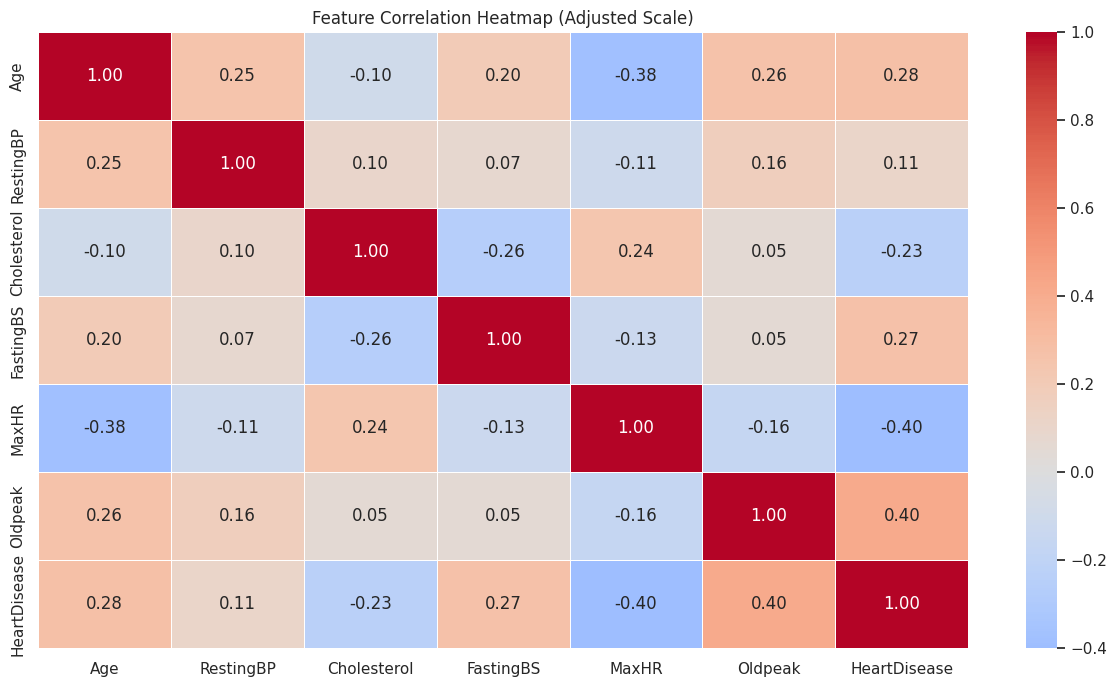

In [182]:
plt.figure(figsize=(15,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    # vmin=-0.1, vmax=0.1,
    center=0
)

plt.title("Feature Correlation Heatmap (Adjusted Scale)")
plt.show()

In [183]:
!pip install boruta

In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from boruta import BorutaPy

In [185]:
# Step 1: Prepare data
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Step 2: Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Step 3: Convert to numpy
X = X.values
y = y.values

# Step 4: Define model
forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 5: Apply Boruta
feat_selector = BorutaPy(forest, n_estimators='auto', verbose=2)

feat_selector.fit(X, y)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	9 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	10 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	11 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	12 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	13 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	14 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	15 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	16 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration:

BorutaPy(estimator=RandomForestClassifier(n_estimators=40,
                                          random_state=RandomState(MT19937) at 0x7E3C3C110340),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7E3C3C110340, verbose=2)

In [186]:
# Get feature names
feature_names = pd.get_dummies(df.drop(columns=['HeartDisease']), drop_first=True).columns

# Get selected features
important_features = feature_names[feat_selector.support_]

print("Important Features:")
print(important_features)

Important Features:
Index(['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [187]:
X_selected = pd.DataFrame(X, columns=feature_names)[important_features]

In [188]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8097826086956522


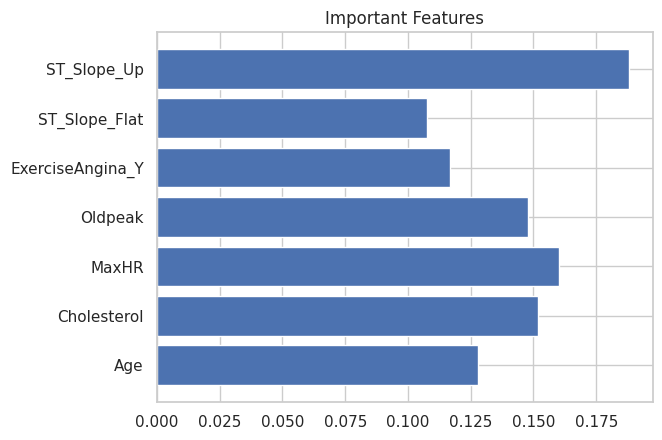

In [189]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(important_features, importances)
plt.title("Important Features")
plt.show()

In [193]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from boruta import BorutaPy

# Step 1: Train full model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_full = RandomForestClassifier(n_estimators=100, random_state=42)
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)
print("Accuracy with all features:", accuracy_full)

# Step 2: Apply Boruta
rf = RandomForestClassifier(n_estimators=100, random_state=42)
boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42)
boruta_selector.fit(X, y)

# Step 3: Get Boruta-selected features
selected_features = feature_names[boruta_selector.support_]
X_selected = pd.DataFrame(X, columns=feature_names)[selected_features]

# Step 4: Train model on Boruta-selected features
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)
model_sel = RandomForestClassifier(n_estimators=100, random_state=42)
model_sel.fit(X_train_sel, y_train_sel)
y_pred_sel = model_sel.predict(X_test_sel)
accuracy_sel = accuracy_score(y_test_sel, y_pred_sel)
print("Accuracy with Boruta-selected features:", accuracy_sel)

# Step 5: Decide whether to reduce features (1% tolerance)
tolerance = 0.01  # 1% drop allowed
if accuracy_sel >= accuracy_full:
    print("\n✅ Feature reduction successful! Use Boruta-selected features:")
    print(list(selected_features))
    print("Accuracy:", accuracy_sel)
elif (accuracy_full - accuracy_sel) <= tolerance:
    print("\n⚠️ Slight accuracy drop (≤1%). You can still use reduced features if efficiency matters:")
    print(list(selected_features))
    print("Accuracy:", accuracy_sel)
else:
    print("\n❌ Accuracy dropped too much. Keep all features.")
    print("Use all features. Accuracy:", accuracy_full)

Accuracy with all features: 0.875
Accuracy with Boruta-selected features: 0.8097826086956522

❌ Accuracy dropped too much. Keep all features.
Use all features. Accuracy: 0.875


In [195]:
# Using the chosen features
final_X = X_selected if (accuracy_sel >= accuracy_full or (accuracy_full - accuracy_sel) <= 0.01) else pd.DataFrame(X, columns=feature_names)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(final_X, y, test_size=0.2, random_state=42)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_final, y_train_final)

y_pred_final = final_model.predict(X_test_final)
final_accuracy = accuracy_score(y_test_final, y_pred_final)
print("✅ Final Model Accuracy:", final_accuracy)
print("📌 Final Features Used:", list(final_X.columns))

✅ Final Model Accuracy: 0.875
📌 Final Features Used: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [196]:
import statsmodels.api as sm

In [203]:
X_top = final_X
y = df['HeartDisease']

In [204]:
print(X_top.dtypes)
print(y.dtypes)

Age                  object
RestingBP            object
Cholesterol          object
FastingBS            object
MaxHR                object
Oldpeak              object
Sex_M                object
ChestPainType_ATA    object
ChestPainType_NAP    object
ChestPainType_TA     object
RestingECG_Normal    object
RestingECG_ST        object
ExerciseAngina_Y     object
ST_Slope_Flat        object
ST_Slope_Up          object
dtype: object
int64


In [205]:
X_top = X_top.astype(float)
y = y.astype(float)

In [206]:
import statsmodels.api as sm

X_top = sm.add_constant(X_top)

In [207]:
res = sm.Logit(y,X_top).fit()
res.summary()

Optimization terminated successfully.
         Current function value: 0.323630
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           HeartDisease   No. Observations:                  918
Model:                          Logit   Df Residuals:                      902
Method:                           MLE   Df Model:                           15
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.5292
Time:                        07:55:32   Log-Likelihood:                -297.09
converged:                       True   LL-Null:                       -631.07
Covariance Type:            nonrobust   LLR p-value:                1.250e-132
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.1637      1.416     -0.822      0.411      -3.939       1.612
Age                   0.0166      0.013      1.254      0.210      -0.009       0.042
RestingBP             0.0042      0.006      0.698      0.485      -0.008       0.016
Cholesterol          -0.0041      0.001     -3.785      0.000      -0.006      -0.002
FastingBS             1.1365      0.275      4.133      0.000       0.597       1.675
MaxHR                -0.0043      0.005     -0.854      0.393      -0.014       0.006
Oldpeak               0.3806      0.118      3.213      0.001       0.148       0.613
Sex_M                 1.4665      0.280      5.241      0.000       0.918       2.015
ChestPainType_ATA    -1.8303      0.326     -5.609      0.000      -2.470      -1.191
ChestPainType_NAP    -1.6857      0.266     -6.337      0.000      -2.207      -1.164
ChestPainType_TA     -1.4884      0.433     -3.441      0.001      -2.336      -0.641
RestingECG_Normal    -0.1770      0.272     -0.651      0.515      -0.710       0.356
RestingECG_ST        -0.2685      0.350     -0.767      0.443      -0.955       0.417
ExerciseAngina_Y      0.9003      0.245      3.682      0.000       0.421       1.380
ST_Slope_Flat         1.4539      0.429      3.388      0.001       0.613       2.295
ST_Slope_Up          -0.9941      0.450     -2.208      0.027      -1.876      -0.112
=====================================================================================
"""

In [209]:
from sklearn.metrics import accuracy_score, recall_score

y_pred = final_model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("Recall:", recall_score(y_test_final, y_pred))

Accuracy: 0.875
Recall: 0.8878504672897196


In [210]:
import numpy as np
import pandas as pd

def analyze_logistic_model(res, alpha=0.05):
    """
    res : fitted logistic regression model (statsmodels)
    alpha : significance level (default 0.05 for 95% CI)
    """

    # Get parameters and confidence intervals
    params = res.params
    conf = res.conf_int(alpha=alpha)

    # Rename columns
    conf.columns = ['lower', 'upper']

    # Add odds ratio
    conf['odds_ratio'] = params

    # Convert to exponent (important!)
    conf_exp = np.exp(conf)

    # Lists to store features
    risk_increase = []
    risk_decrease = []
    no_effect = []

    # Classification logic
    for feature in conf_exp.index:
        lower = conf_exp.loc[feature, 'lower']
        upper = conf_exp.loc[feature, 'upper']
        odds = conf_exp.loc[feature, 'odds_ratio']

        if lower > 1:
            risk_increase.append(feature)
        elif upper < 1:
            risk_decrease.append(feature)
        else:
            no_effect.append(feature)

    return conf_exp, risk_increase, risk_decrease, no_effect

In [211]:
conf_table, inc, dec, no_eff = analyze_logistic_model(res)

print("Odds Ratio Table:\n", conf_table)

print("\n📈 Risk Increasing Features:", inc)
print("📉 Risk Decreasing Features:", dec)
print("⚖️ No Significant Effect:", no_eff)

Odds Ratio Table:
                       lower     upper  odds_ratio
const              0.019468  5.011120    0.312342
Age                0.990728  1.043328    1.016688
RestingBP          0.992444  1.016100    1.004202
Cholesterol        0.993774  0.998018    0.995894
FastingBS          1.817558  5.341309    3.115789
MaxHR              0.985968  1.005571    0.995721
Oldpeak            1.160040  1.845651    1.463226
Sex_M              2.504312  7.500286    4.333942
ChestPainType_ATA  0.084601  0.303988    0.160367
ChestPainType_NAP  0.110026  0.312132    0.185318
ChestPainType_TA   0.096693  0.526994    0.225735
RestingECG_Normal  0.491646  1.427507    0.837752
RestingECG_ST      0.384976  1.518133    0.764490
ExerciseAngina_Y   1.523570  3.973026    2.460321
ST_Slope_Flat      1.845792  9.923393    4.279780
ST_Slope_Up        0.153130  0.894283    0.370056

📈 Risk Increasing Features: ['FastingBS', 'Oldpeak', 'Sex_M', 'ExerciseAngina_Y', 'ST_Slope_Flat']
📉 Risk Decreasing Features: ['C